<a href="https://colab.research.google.com/github/ravithreni02/AI-ML-INTERNSHIP/blob/main/agrigenie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

rm: cannot remove '/content/drive/Shareddrives': Operation canceled
rm: cannot remove '/content/drive/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Cell 1 of every session — always run this FIRST, before anything else
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
PROJECT_DIR = "/content/drive/MyDrive/AgriGenie"
os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/models", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/outputs", exist_ok=True)
print("Ready:", PROJECT_DIR)

Mounted at /content/drive
Ready: /content/drive/MyDrive/AgriGenie


### Saving raw datasets to Google Drive for persistence

This step ensures that all the raw dataframes loaded or fetched during this notebook run are saved to your Google Drive. This way, you won't need to re-download or re-fetch them in future sessions, saving time and API calls.

In [3]:
import pandas as pd

# Load dataframes if they are not already defined
# (Assuming PROJECT_DIR is already defined from a previous cell)

# For df (from cell fMpHyaHi-YDu)
url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
df = pd.read_csv(url)

# For price_df (from cell CBSUJSrsF1EB)
price_df = pd.read_csv("/content/agmarknet_india_historical_prices_2024_2025.csv")

# For nasa_df (from cell j23lgI2bYaTP) - initializing to None to avoid complex dependency duplication
nasa_df = None

# For wf_df (from cell OSW4KKqKYz0A)
wf_df = pd.read_csv(f"/content/national_wf_all_crops_1990_2019.csv")

# For yield_df (from cell Bj58ej89JwA-)
yield_df = pd.read_csv(f"/content/India Agriculture Crop Production.csv")

# For yield_df2 (from cell elQajxGnW0Ia)
yield_df2 = pd.read_csv(f"/content/crop_yield.csv")

# For cost1 (from cell IuG5mXOEZCaj)
cost1 = pd.read_csv(f"/content/culti_cost.csv")

# Original code to save dataframes
df.to_csv(f"{PROJECT_DIR}/data/crop_recommendation_raw.csv", index=False)
print("Saved crop_recommendation_raw.csv")

price_df.to_csv(f"{PROJECT_DIR}/data/agmarknet_historical_prices_raw.csv", index=False)
print("Saved agmarknet_historical_prices_raw.csv")

if nasa_df is not None:
    nasa_df.to_csv(f"{PROJECT_DIR}/data/nasa_power_data_raw.csv", index=False)
    print("Saved nasa_power_data_raw.csv")

wf_df.to_csv(f"{PROJECT_DIR}/data/national_wf_all_crops_raw.csv", index=False)
print("Saved national_wf_all_crops_raw.csv")

yield_df.to_csv(f"{PROJECT_DIR}/data/india_agriculture_crop_production_raw.csv", index=False)
print("Saved india_agriculture_crop_production_raw.csv")

yield_df2.to_csv(f"{PROJECT_DIR}/data/crop_yield_raw.csv", index=False)
print("Saved crop_yield_raw.csv")

cost1.to_csv(f"{PROJECT_DIR}/data/culti_cost_raw.csv", index=False)
print("Saved culti_cost_raw.csv")

Saved crop_recommendation_raw.csv
Saved agmarknet_historical_prices_raw.csv
Saved national_wf_all_crops_raw.csv
Saved india_agriculture_crop_production_raw.csv
Saved crop_yield_raw.csv
Saved culti_cost_raw.csv


In [4]:
import os
path = f"{PROJECT_DIR}/data/crop_benchmarks.csv"
print("Exists:", os.path.exists(path))

Exists: False


In [5]:
!pip install xgboost lightgbm shap -q

In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/AbhishekKandoi/Crop-Yield-Prediction-based-on-Indian-Agriculture/main/Crop%20Recommendation%20dataset.csv"
df = pd.read_csv(url)
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [7]:
print(df.shape)                 # should print (2200, 8)
print(df.isnull().sum())        # should be all 0
print(df['label'].value_counts())  # should show 22 crops, 100 rows each
df.describe()

(2200, 8)
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [8]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET = "label"

X = df[FEATURES]
y_raw = df[TARGET].values

le = LabelEncoder()
y = le.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(X_train_s.shape, X_test_s.shape)

(1760, 7) (440, 7)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_s, y_train)
preds = rf.predict(X_test_s)

print("Accuracy:", accuracy_score(y_test, preds))
print("F1 macro:", f1_score(y_test, preds, average="macro"))

Accuracy: 0.9954545454545455
F1 macro: 0.9954517027687758


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, eval_metric="mlogloss", random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=300, random_state=42, verbose=-1),
}

results = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    results.append({"model": name, "accuracy": round(acc*100, 2), "f1_macro": round(f1*100, 2)})
    print(f"{name:20s} | Acc: {acc*100:.2f}% | F1: {f1*100:.2f}%")

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
results_df

LogisticRegression   | Acc: 97.27% | F1: 97.25%
KNN                  | Acc: 97.95% | F1: 97.93%
DecisionTree         | Acc: 97.95% | F1: 97.94%
RandomForest         | Acc: 99.55% | F1: 99.55%
SVM                  | Acc: 98.41% | F1: 98.40%
XGBoost              | Acc: 98.86% | F1: 98.86%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM             | Acc: 98.86% | F1: 98.86%


,model,accuracy,f1_macro
3,RandomForest,99.55,99.55
5,XGBoost,98.86,98.86
6,LightGBM,98.86,98.86
4,SVM,98.41,98.40
2,DecisionTree,97.95,97.94
1,KNN,97.95,97.93
0,LogisticRegression,97.27,97.25


In [11]:
import joblib

best_model = models["RandomForest"]
joblib.dump(best_model, "best_model_RandomForest.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(le, "label_encoder.joblib")

print("Saved!")

Saved!


In [12]:
import shap
import numpy as np

X_test_s_df = pd.DataFrame(X_test_s, columns=FEATURES)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_s_df.iloc[:200])

print(type(shap_values))
if isinstance(shap_values, list):
    print(len(shap_values), shap_values[0].shape)
else:
    print(shap_values.shape)

<class 'numpy.ndarray'>
(200, 7, 22)


In [13]:
if isinstance(shap_values, list):
    # older SHAP: list of (samples, features) arrays, one per class
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    # newer SHAP: single array of shape (samples, features, classes)
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

print(mean_abs_shap.shape)   # should print (7,) — one value per feature
importance_df = pd.DataFrame({"feature": FEATURES, "importance": mean_abs_shap}).sort_values("importance", ascending=False)
importance_df

(7,)


,feature,importance
4,humidity,0.031998
2,K,0.027688
6,rainfall,0.025847
0,N,0.025501
1,P,0.024540
3,temperature,0.010238
5,ph,0.005008


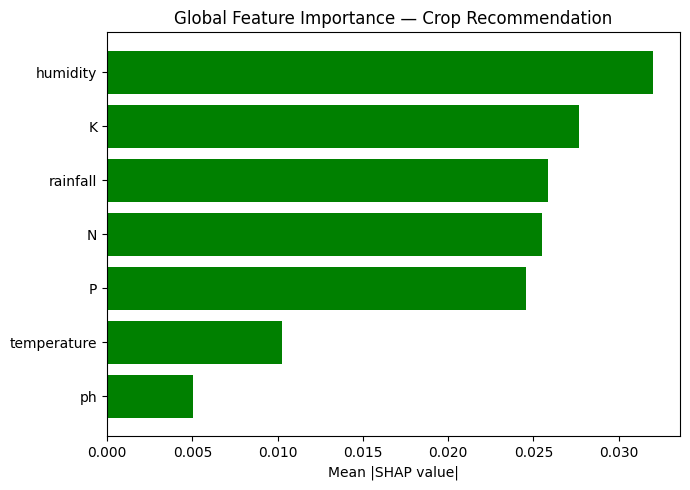

In [14]:
import matplotlib.pyplot as plt

# Explicitly sort ascending to naturally plot highest importance values at the top hook
plot_df = importance_df.sort_values("importance", ascending=True)

plt.figure(figsize=(7,5))
plt.barh(plot_df["feature"], plot_df["importance"], color="green")
plt.xlabel("Mean |SHAP value|")
plt.title("Global Feature Importance — Crop Recommendation")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150)
plt.show()


In [15]:
sample = X_test_s_df.iloc[[0]]
pred_idx = best_model.predict(sample)[0]
pred_crop = le.inverse_transform([pred_idx])[0]

print("Recommended crop:", pred_crop)
print("Input values:", dict(zip(FEATURES, X_test.tolist()[0]) if False else zip(FEATURES, sample.values[0])))

Recommended crop: orange
Input values: {'N': np.float64(-1.0188693731725638), 'P': np.float64(-0.9211104081895409), 'K': np.float64(-0.8313183926160046), 'temperature': np.float64(-0.3244648252864654), 'humidity': np.float64(0.8461388789654121), 'ph': np.float64(1.1384809702385095), 'rainfall': np.float64(-0.01374610723604659)}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [16]:
#day 2

In [17]:
import pandas as pd
price_df = pd.read_csv("/content/agmarknet_india_historical_prices_2024_2025.csv")
print(price_df.shape)
price_df.head()

(1118899, 11)


,Sl no.,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date,State
0,1,Auraiya,Achalda,Wheat,Dara,FAQ,2350.0,2550.0,2450.0,05 Apr 2025,Uttar Pradesh
1,2,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2500.0,2470.0,14 Jun 2025,Uttar Pradesh
2,3,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2500.0,2470.0,23 Jun 2025,Uttar Pradesh
3,4,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2520.0,2470.0,26 Jun 2025,Uttar Pradesh
4,5,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2550.0,2500.0,03 Jun 2025,Uttar Pradesh


In [18]:
crop_benchmarks = {
    "rice":        [4.0, 1200, 20, 45000, 25, 200],
    "maize":       [3.0, 500,  18, 30000, 24, 90],
    "chickpea":    [1.2, 350,  55, 25000, 22, 65],
    "kidneybeans": [1.5, 400,  60, 28000, 20, 90],
    "pigeonpeas":  [1.0, 450,  70, 26000, 26, 150],
    "mothbeans":   [0.7, 300,  55, 18000, 28, 55],
    "mungbean":    [0.8, 350,  70, 20000, 27, 60],
    "blackgram":   [0.8, 350,  65, 20000, 27, 65],
    "lentil":      [1.0, 300,  60, 22000, 20, 45],
    "pomegranate": [10.0, 800, 80, 150000, 22, 60],
    "banana":      [35.0, 1800, 15, 180000, 26, 110],
    "mango":       [8.0, 900,  40, 90000, 27, 90],
    "grapes":      [18.0, 700, 45, 200000, 20, 70],
    "watermelon":  [25.0, 500, 8,  60000, 25, 45],
    "muskmelon":   [15.0, 450, 12, 55000, 26, 30],
    "apple":       [15.0, 1000, 60, 120000, 12, 110],
    "orange":      [12.0, 900, 25, 85000, 22, 110],
    "papaya":      [40.0, 1000, 12, 70000, 26, 140],
    "coconut":     [8.0,  1300, 20, 60000, 27, 150],
    "cotton":      [1.8, 700,  60, 40000, 26, 80],
    "jute":        [2.5, 1200, 40, 35000, 25, 170],
    "coffee":      [1.0, 1500, 250, 100000, 24, 180],
}

bench_df = pd.DataFrame.from_dict(
    crop_benchmarks, orient="index",
    columns=["avg_yield_t_ha", "water_req_mm", "price_per_kg_inr",
             "cost_cultivation_inr_ha", "ideal_temp_c", "ideal_rainfall_mm"]
).reset_index().rename(columns={"index": "label"})

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks.csv", index=False)
print("Base table rebuilt and saved")

Base table rebuilt and saved


In [19]:
print(sorted(price_df["Commodity"].unique()))

['Apple', 'Arhar (Tur/Red Gram)(Whole)', 'Bajra(Pearl Millet/Cumbu)', 'Banana', 'Bhindi(Ladies Finger)', 'Brinjal', 'Cabbage', 'Carrot', 'Cauliflower', 'Cotton', 'Garlic', 'Ginger(Green)', 'Green Chilli', 'Green Gram (Moong)(Whole)', 'Groundnut', 'Gur(Jaggery)', 'Jowar(Sorghum)', 'Lentil (Masur)(Whole)', 'Maize', 'Mango', 'Mustard', 'Soyabean', 'Wheat']


In [20]:
price_summary = price_df.groupby("Commodity")["Modal Price (Rs./Quintal)"].mean().reset_index()
price_summary["price_per_kg_inr"] = (price_summary["Modal Price (Rs./Quintal)"] / 100).round(2)
price_summary

,Commodity,Modal Price (Rs./Quintal),price_per_kg_inr
0,Apple,9004.111406,90.04
1,Arhar (Tur/Red Gram)(Whole),7286.404794,72.86
2,Bajra(Pearl Millet/Cumbu),2403.442858,24.03
3,Banana,2573.836778,25.74
4,Bhindi(Ladies Finger),3014.642133,30.15
5,Brinjal,2317.671478,23.18
6,Cabbage,1884.678058,18.85
7,Carrot,3581.302746,35.81
8,Cauliflower,2332.924583,23.33
9,Cotton,7106.537475,71.07


In [21]:
name_mapping = {
    "Maize": "maize",
    "Arhar (Tur/Red Gram)(Whole)": "pigeonpeas",
    "Banana": "banana",
    "Mango": "mango",
    "Cotton": "cotton",
    "Green Gram (Moong)(Whole)": "mungbean",
    "Lentil (Masur)(Whole)": "lentil",
    "Apple": "apple",
}

price_summary["label"] = price_summary["Commodity"].map(name_mapping)
matched_df = price_summary.dropna(subset=["label"])[["label", "price_per_kg_inr"]]
matched_df["price_data_year"] = "2024-2025 avg"
matched_df["price_source"] = "Agmarknet historical dataset (Oct 2024 - Aug 2025), CC BY-SA 4.0"
matched_df

,label,price_per_kg_inr,price_data_year,price_source
0,apple,90.04,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
1,pigeonpeas,72.86,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
3,banana,25.74,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
9,cotton,71.07,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
13,mungbean,73.03,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
17,lentil,63.06,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
18,maize,22.10,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...
19,mango,45.09,2024-2025 avg,Agmarknet historical dataset (Oct 2024 - Aug 2...


In [22]:
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks.csv")
bench_df = bench_df.drop(columns=["price_per_kg_inr"], errors="ignore")
bench_df = bench_df.merge(matched_df, on="label", how="left")
bench_df["price_source"] = bench_df["price_source"].fillna("estimated_placeholder")

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_real.csv", index=False)
bench_df[["label", "price_per_kg_inr", "price_source"]]

,label,price_per_kg_inr,price_source
0,rice,NaN,estimated_placeholder
1,maize,22.10,Agmarknet historical dataset (Oct 2024 - Aug 2...
2,chickpea,NaN,estimated_placeholder
3,kidneybeans,NaN,estimated_placeholder
4,pigeonpeas,72.86,Agmarknet historical dataset (Oct 2024 - Aug 2...
5,mothbeans,NaN,estimated_placeholder
6,mungbean,73.03,Agmarknet historical dataset (Oct 2024 - Aug 2...
7,blackgram,NaN,estimated_placeholder
8,lentil,63.06,Agmarknet historical dataset (Oct 2024 - Aug 2...
9,pomegranate,NaN,estimated_placeholder


In [23]:
state_price = price_df.groupby(["Commodity", "State"])["Modal Price (Rs./Quintal)"].mean().reset_index()
state_price["price_per_kg_inr"] = (state_price["Modal Price (Rs./Quintal)"] / 100).round(2)
state_price = state_price.rename(columns={"Commodity": "commodity", "State": "state"})[["commodity", "state", "price_per_kg_inr"]]

state_price.to_csv(f"{PROJECT_DIR}/data/state_wise_prices.csv", index=False)
print(state_price.shape)
state_price.head(10)

(146, 3)


,commodity,state,price_per_kg_inr
0,Apple,Gujarat,104.84
1,Apple,Kerala,165.55
2,Apple,Madhya Pradesh,63.07
3,Apple,Punjab,83.01
4,Apple,Rajasthan,82.04
5,Apple,Uttar Pradesh,85.24
6,Apple,West Bengal,127.88
7,Arhar (Tur/Red Gram)(Whole),Andhra Pradesh,63.25
8,Arhar (Tur/Red Gram)(Whole),Gujarat,67.07
9,Arhar (Tur/Red Gram)(Whole),Kerala,132.92


In [24]:
price_spread = state_price.groupby("commodity")["price_per_kg_inr"].agg(["min", "max", "mean", "std"]).reset_index()
price_spread["price_range_pct"] = ((price_spread["max"] - price_spread["min"]) / price_spread["mean"] * 100).round(1)
price_spread.sort_values("price_range_pct", ascending=False)

,commodity,min,max,mean,std,price_range_pct
7,Carrot,13.17,65.30,26.277143,19.707827,198.4
8,Cauliflower,10.57,47.39,21.901250,11.257524,168.1
6,Cabbage,9.22,34.26,15.451250,7.938516,162.1
10,Garlic,99.25,288.36,150.297143,66.950608,125.8
5,Brinjal,12.31,39.25,22.067500,9.289075,122.1
14,Groundnut,46.09,113.62,61.586667,25.775116,109.7
11,Ginger(Green),33.55,89.29,51.752857,19.312260,107.7
19,Mango,20.25,65.08,44.221250,16.051958,101.4
0,Apple,63.07,165.55,101.661429,34.811646,100.8
1,Arhar (Tur/Red Gram)(Whole),58.83,132.92,84.457143,27.956772,87.7


In [25]:
def get_price_for_state(crop, state, state_price_df, national_avg_df):
    """Returns state-specific price if available, else falls back to national average."""
    row = state_price_df[(state_price_df["commodity"].str.lower().str.contains(crop, na=False)) &
                          (state_price_df["state"] == state)]
    if not row.empty:
        return row.iloc[0]["price_per_kg_inr"], "state_specific"
    # fallback to national average from your matched_df / bench_df
    fallback = national_avg_df[national_avg_df["label"] == crop]
    if not fallback.empty:
        return fallback.iloc[0]["price_per_kg_inr"], "national_average_fallback"
    return None, "unavailable"

# example
price, source = get_price_for_state("maize", "Punjab", state_price, matched_df)
print(price, source)

20.66 state_specific


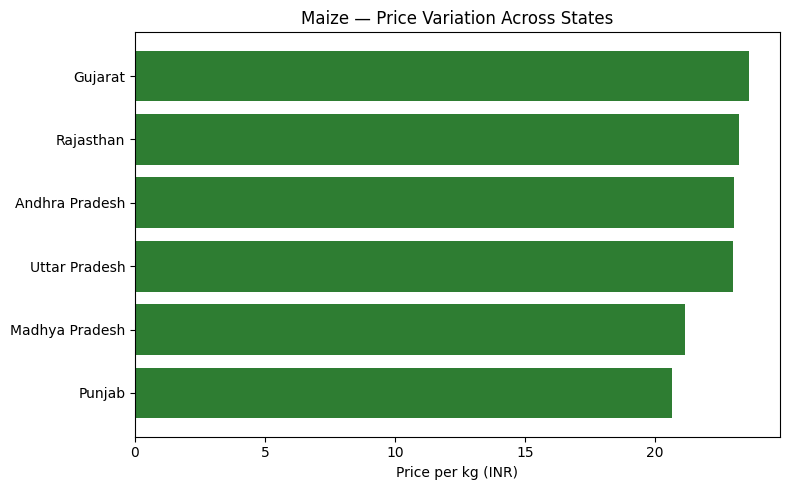

In [26]:
import matplotlib.pyplot as plt

top_commodity = "Maize"  # pick any commodity with good state coverage
plot_data = state_price[state_price["commodity"] == top_commodity].sort_values("price_per_kg_inr")

plt.figure(figsize=(8,5))
plt.barh(plot_data["state"], plot_data["price_per_kg_inr"], color="#2E7D32")
plt.xlabel("Price per kg (INR)")
plt.title(f"{top_commodity} — Price Variation Across States")
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/outputs/state_price_variation_{top_commodity.lower()}.png", dpi=150)
plt.show()

In [27]:
import pandas as pd

yield_df = pd.read_csv(f"/content/India Agriculture Crop Production.csv")
yield_df = yield_df.dropna(subset=["Crop", "Yield"])

name_mapping = {
    "Rice": "rice", "Maize": "maize", "Arhar/Tur": "pigeonpeas",
    "Banana": "banana", "Coconut": "coconut", "Cotton(lint)": "cotton",
    "Gram": "chickpea", "Jute": "jute", "Moong(Green Gram)": "mungbean",
    "Urad": "blackgram", "Masoor": "lentil",
}
yield_df["label"] = yield_df["Crop"].map(name_mapping)
matched_yield = yield_df.dropna(subset=["label"])

yield_summary = matched_yield.groupby("label")["Yield"].mean().reset_index()
yield_summary.columns = ["label", "avg_yield_t_ha_real"]
yield_summary["yield_source"] = "India Agriculture Crop Production dataset (1997-2020 avg)"
yield_summary

,label,avg_yield_t_ha_real,yield_source
0,banana,29.227150,India Agriculture Crop Production dataset (199...
1,blackgram,0.541447,India Agriculture Crop Production dataset (199...
2,chickpea,0.878775,India Agriculture Crop Production dataset (199...
3,coconut,8833.247618,India Agriculture Crop Production dataset (199...
4,cotton,2.111284,India Agriculture Crop Production dataset (199...
5,jute,9.387099,India Agriculture Crop Production dataset (199...
6,lentil,0.738228,India Agriculture Crop Production dataset (199...
7,maize,2.653406,India Agriculture Crop Production dataset (199...
8,mungbean,0.492162,India Agriculture Crop Production dataset (199...
9,pigeonpeas,0.874560,India Agriculture Crop Production dataset (199...


In [28]:
yield_df2 = pd.read_csv(f"/content/crop_yield.csv")
moth_row = yield_df2[yield_df2["Crop"].str.strip() == "Moth"]
if not moth_row.empty:
    moth_avg_yield = moth_row["Yield"].mean()
    print("Mothbeans avg yield:", moth_avg_yield)

Mothbeans avg yield: 0.4459953350454546


In [29]:
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_real.csv")  # your table with real prices already merged
bench_df = bench_df.merge(yield_summary, on="label", how="left")

# use real yield where available, fall back to placeholder otherwise
bench_df["avg_yield_t_ha"] = bench_df["avg_yield_t_ha_real"].fillna(bench_df["avg_yield_t_ha"])
bench_df["yield_source"] = bench_df["yield_source"].fillna("estimated_placeholder")

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_final.csv", index=False)
bench_df[["label", "avg_yield_t_ha", "yield_source", "price_per_kg_inr", "price_source"]]

,label,avg_yield_t_ha,yield_source,price_per_kg_inr,price_source
0,rice,2.098431,India Agriculture Crop Production dataset (199...,NaN,estimated_placeholder
1,maize,2.653406,India Agriculture Crop Production dataset (199...,22.10,Agmarknet historical dataset (Oct 2024 - Aug 2...
2,chickpea,0.878775,India Agriculture Crop Production dataset (199...,NaN,estimated_placeholder
3,kidneybeans,1.500000,estimated_placeholder,NaN,estimated_placeholder
4,pigeonpeas,0.874560,India Agriculture Crop Production dataset (199...,72.86,Agmarknet historical dataset (Oct 2024 - Aug 2...
5,mothbeans,0.700000,estimated_placeholder,NaN,estimated_placeholder
6,mungbean,0.492162,India Agriculture Crop Production dataset (199...,73.03,Agmarknet historical dataset (Oct 2024 - Aug 2...
7,blackgram,0.541447,India Agriculture Crop Production dataset (199...,NaN,estimated_placeholder
8,lentil,0.738228,India Agriculture Crop Production dataset (199...,63.06,Agmarknet historical dataset (Oct 2024 - Aug 2...
9,pomegranate,10.000000,estimated_placeholder,NaN,estimated_placeholder


In [30]:
# Quick fix: don't trust the real value for coconut, keep the placeholder instead
bench_df.loc[bench_df["label"] == "coconut", "avg_yield_t_ha"] = 8.0  # revert to placeholder
bench_df.loc[bench_df["label"] == "coconut", "yield_source"] = "estimated_placeholder (unit mismatch in source: nuts/ha, not tonnes/ha)"

In [31]:
bench_df.loc[bench_df["label"] == "mothbeans", "avg_yield_t_ha"] = round(moth_avg_yield, 3)
bench_df.loc[bench_df["label"] == "mothbeans", "yield_source"] = "crop_yield.csv dataset (real, 1997-2020 avg)"

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_final.csv", index=False)
bench_df[["label", "avg_yield_t_ha", "yield_source"]]

,label,avg_yield_t_ha,yield_source
0,rice,2.098431,India Agriculture Crop Production dataset (199...
1,maize,2.653406,India Agriculture Crop Production dataset (199...
2,chickpea,0.878775,India Agriculture Crop Production dataset (199...
3,kidneybeans,1.500000,estimated_placeholder
4,pigeonpeas,0.874560,India Agriculture Crop Production dataset (199...
5,mothbeans,0.446000,"crop_yield.csv dataset (real, 1997-2020 avg)"
6,mungbean,0.492162,India Agriculture Crop Production dataset (199...
7,blackgram,0.541447,India Agriculture Crop Production dataset (199...
8,lentil,0.738228,India Agriculture Crop Production dataset (199...
9,pomegranate,10.000000,estimated_placeholder


In [32]:
import requests
import pandas as pd

def fetch_nasa_power_data(lat, lon, start_date, end_date):
    # Core NASA POWER single-point daily API gateway
    url = "https://power.larc.nasa.gov/api/temporal/daily/point"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start": start_date,  # Format: YYYYMMDD
        "end": end_date,      # Format: YYYYMMDD
        "community": "AG",    # Agroclimatology optimized data
        "parameters": "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,ALLSKY_SFC_SW_DWN,GWETTOP",
        "format": "JSON"
    }

    try:
        response = requests.get(url, params=params, timeout=20)
        response.raise_for_status()
        data = response.json()

        # Parse the structured multi-dimensional dictionary parameter map
        records = data["properties"]["parameter"]

        # Load the time-series JSON matrices directly into a Pandas Table
        df = pd.DataFrame(records)
        df.index = pd.to_datetime(df.index, format="%Y%m%d")
        df = df.reset_index().rename(columns={"index": "date"})

        # Rename columns to clear semantic agronomic variables
        df = df.rename(columns={
            "PRECTOTCORR": "rainfall_mm",
            "T2M": "avg_temp_c",
            "ALLSKY_SFC_SW_DWN": "solar_radiation",
            "GWETTOP": "soil_moisture_top"
        })

        return df

    except requests.exceptions.RequestException as e:
        print(f"NASA API connection error: {e}")
        return None

# Test Run: Extracting data for an agricultural zone in India during the 2023 climate anomaly
nasa_df = fetch_nasa_power_data(lat=17.38, lon=78.48, start_date="20230601", end_date="20231130")

if nasa_df is not None:
    print(nasa_df.head())


        date  avg_temp_c  T2M_MAX  T2M_MIN  rainfall_mm  solar_radiation  \
0 2023-06-01       33.29    40.30    26.25         0.01            24.05   
1 2023-06-02       33.89    41.05    27.17         0.15            27.23   
2 2023-06-03       34.54    41.02    27.34         0.17            25.25   
3 2023-06-04       33.27    38.94    28.50         1.91            17.35   
4 2023-06-05       32.40    38.81    26.29         0.00            24.81   

   soil_moisture_top  
0               0.37  
1               0.34  
2               0.32  
3               0.34  
4               0.34  


In [33]:
wf_df = pd.read_csv(f"/content/national_wf_all_crops_1990_2019.csv")
india_wf = wf_df[wf_df["country_name"] == "India"]
recent_wf = india_wf[india_wf["year"] >= 2015]  # use recent years only

wf_name_mapping = {
    "Maize (corn)": "maize", "Rice": "rice", "Seed cotton, unginned": "cotton",
    "Chick peas, dry": "chickpea", "Pigeon peas, dry": "pigeonpeas",
    "Lentils, dry": "lentil", "Grapes": "grapes", "Coffee, green": "coffee",
    "Coconuts, in shell": "coconut", "Bananas": "banana", "Apples": "apple",
    "Oranges": "orange", "Watermelons": "watermelon", "Papayas": "papaya",
    "Mangoes, guavas and mangosteens": "mango", "Jute, raw or retted": "jute",
    "Beans, dry": "kidneybeans",
}
recent_wf["label"] = recent_wf["crop_name"].map(wf_name_mapping)
matched_wf = recent_wf.dropna(subset=["label"])

wf_summary = matched_wf.groupby("label").agg(
    wf_m3_per_t=("wf_tot_m3_t", "mean"),
    yield_t_ha=("crop_yield_t_ha", "mean")
).reset_index()

# convert m3/tonne -> mm water depth per hectare: 1mm over 1 ha = 10 m3
wf_summary["water_req_mm_real"] = (wf_summary["wf_m3_per_t"] * wf_summary["yield_t_ha"] / 10).round(1)
wf_summary["water_source"] = "FAO/WaterFootprint national dataset (India, 2015-2019 avg)"

wf_summary[["label", "water_req_mm_real", "water_source"]]

/tmp/ipykernel_119923/622702329.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_wf["label"] = recent_wf["crop_name"].map(wf_name_mapping)


,label,water_req_mm_real,water_source
0,apple,509.3,"FAO/WaterFootprint national dataset (India, 20..."
1,banana,633.0,"FAO/WaterFootprint national dataset (India, 20..."
2,chickpea,150.0,"FAO/WaterFootprint national dataset (India, 20..."
3,coconut,652.4,"FAO/WaterFootprint national dataset (India, 20..."
4,coffee,565.5,"FAO/WaterFootprint national dataset (India, 20..."
5,cotton,522.7,"FAO/WaterFootprint national dataset (India, 20..."
6,grapes,375.3,"FAO/WaterFootprint national dataset (India, 20..."
7,jute,186.3,"FAO/WaterFootprint national dataset (India, 20..."
8,kidneybeans,152.2,"FAO/WaterFootprint national dataset (India, 20..."
9,lentil,179.7,"FAO/WaterFootprint national dataset (India, 20..."


In [34]:
cost1 = pd.read_csv(f"/content/culti_cost.csv")
cost1_avg = cost1.filter(like="C2 - 2013-14").mean(axis=1)  # latest year, C2 = full economic cost
cost1_clean = pd.DataFrame({"Crop": cost1["Crop"], "cost_inr_ha": cost1_avg}).groupby("Crop").mean().reset_index()

cost_name_mapping = {"Paddy": "rice", "Maize": "maize", "Gram": "chickpea",
                      "Arhar": "pigeonpeas", "Cotton": "cotton", "Moong": "mungbean"}
cost1_clean["label"] = cost1_clean["Crop"].map(cost_name_mapping)
matched_cost = cost1_clean.dropna(subset=["label"])[["label", "cost_inr_ha"]]
matched_cost["cost_source"] = "CACP cultivation cost data (2013-14)"
matched_cost

,label,cost_inr_ha,cost_source
0,pigeonpeas,22699.823,CACP cultivation cost data (2013-14)
1,cotton,39144.446,CACP cultivation cost data (2013-14)
2,chickpea,17293.152,CACP cultivation cost data (2013-14)
4,maize,22401.613,CACP cultivation cost data (2013-14)
5,mungbean,14176.831,CACP cultivation cost data (2013-14)
6,rice,30027.858,CACP cultivation cost data (2013-14)


In [35]:
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_final.csv")

bench_df = bench_df.merge(wf_summary[["label","water_req_mm_real","water_source"]], on="label", how="left")
bench_df["water_req_mm"] = bench_df["water_req_mm_real"].fillna(bench_df["water_req_mm"])
bench_df["water_source"] = bench_df["water_source"].fillna("estimated_placeholder")

bench_df = bench_df.merge(matched_cost.rename(columns={"cost_inr_ha":"cost_inr_ha_real"}), on="label", how="left")
bench_df["cost_cultivation_inr_ha"] = bench_df["cost_inr_ha_real"].fillna(bench_df["cost_cultivation_inr_ha"])
bench_df["cost_source"] = bench_df["cost_source"].fillna("estimated_placeholder")

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)
bench_df[["label","avg_yield_t_ha","yield_source","water_req_mm","water_source",
          "price_per_kg_inr","price_source","cost_cultivation_inr_ha","cost_source"]]

,label,avg_yield_t_ha,yield_source,water_req_mm,water_source,price_per_kg_inr,price_source,cost_cultivation_inr_ha,cost_source
0,rice,2.098431,India Agriculture Crop Production dataset (199...,382.9,"FAO/WaterFootprint national dataset (India, 20...",NaN,estimated_placeholder,30027.858,CACP cultivation cost data (2013-14)
1,maize,2.653406,India Agriculture Crop Production dataset (199...,246.8,"FAO/WaterFootprint national dataset (India, 20...",22.10,Agmarknet historical dataset (Oct 2024 - Aug 2...,22401.613,CACP cultivation cost data (2013-14)
2,chickpea,0.878775,India Agriculture Crop Production dataset (199...,150.0,"FAO/WaterFootprint national dataset (India, 20...",NaN,estimated_placeholder,17293.152,CACP cultivation cost data (2013-14)
3,kidneybeans,1.500000,estimated_placeholder,152.2,"FAO/WaterFootprint national dataset (India, 20...",NaN,estimated_placeholder,28000.000,estimated_placeholder
4,pigeonpeas,0.874560,India Agriculture Crop Production dataset (199...,190.7,"FAO/WaterFootprint national dataset (India, 20...",72.86,Agmarknet historical dataset (Oct 2024 - Aug 2...,22699.823,CACP cultivation cost data (2013-14)
5,mothbeans,0.446000,"crop_yield.csv dataset (real, 1997-2020 avg)",300.0,estimated_placeholder,NaN,estimated_placeholder,18000.000,estimated_placeholder
6,mungbean,0.492162,India Agriculture Crop Production dataset (199...,350.0,estimated_placeholder,73.03,Agmarknet historical dataset (Oct 2024 - Aug 2...,14176.831,CACP cultivation cost data (2013-14)
7,blackgram,0.541447,India Agriculture Crop Production dataset (199...,350.0,estimated_placeholder,NaN,estimated_placeholder,20000.000,estimated_placeholder
8,lentil,0.738228,India Agriculture Crop Production dataset (199...,179.7,"FAO/WaterFootprint national dataset (India, 20...",63.06,Agmarknet historical dataset (Oct 2024 - Aug 2...,22000.000,estimated_placeholder
9,pomegranate,10.000000,estimated_placeholder,800.0,estimated_placeholder,NaN,estimated_placeholder,150000.000,estimated_placeholder


In [36]:
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv")

placeholder_prices = {
    "rice": 20, "chickpea": 55, "kidneybeans": 60, "mothbeans": 55,
    "blackgram": 65, "pomegranate": 80, "grapes": 45, "watermelon": 8,
    "muskmelon": 12, "orange": 25, "papaya": 12, "coconut": 20,
    "jute": 40, "coffee": 250,
}

for crop, price in placeholder_prices.items():
    mask = (bench_df["label"] == crop) & (bench_df["price_per_kg_inr"].isna())
    bench_df.loc[mask, "price_per_kg_inr"] = price

# sanity check - should be ZERO nulls now
print("Remaining NaN prices:", bench_df["price_per_kg_inr"].isna().sum())

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)
bench_df[["label", "price_per_kg_inr", "price_source"]]

Remaining NaN prices: 0


,label,price_per_kg_inr,price_source
0,rice,20.00,estimated_placeholder
1,maize,22.10,Agmarknet historical dataset (Oct 2024 - Aug 2...
2,chickpea,55.00,estimated_placeholder
3,kidneybeans,60.00,estimated_placeholder
4,pigeonpeas,72.86,Agmarknet historical dataset (Oct 2024 - Aug 2...
5,mothbeans,55.00,estimated_placeholder
6,mungbean,73.03,Agmarknet historical dataset (Oct 2024 - Aug 2...
7,blackgram,65.00,estimated_placeholder
8,lentil,63.06,Agmarknet historical dataset (Oct 2024 - Aug 2...
9,pomegranate,80.00,estimated_placeholder


In [37]:
fruit_yield_updates = {
    "apple": 6.01,
    "orange": 12.72,   # sourced from "Citrus" category — broader than orange alone, disclose in paper
    "grapes": 26.28,
    "mango": 8.49,
    "papaya": 38.46,
    "pomegranate": 10.79,
}

bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv")

for crop, real_yield in fruit_yield_updates.items():
    mask = bench_df["label"] == crop
    bench_df.loc[mask, "avg_yield_t_ha"] = real_yield
    bench_df.loc[mask, "yield_source"] = "Indian Horticulture Database / National Horticulture Board (2014-15)"

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)
bench_df[["label","avg_yield_t_ha","yield_source"]]


,label,avg_yield_t_ha,yield_source
0,rice,2.098431,India Agriculture Crop Production dataset (199...
1,maize,2.653406,India Agriculture Crop Production dataset (199...
2,chickpea,0.878775,India Agriculture Crop Production dataset (199...
3,kidneybeans,1.500000,estimated_placeholder
4,pigeonpeas,0.874560,India Agriculture Crop Production dataset (199...
5,mothbeans,0.446000,"crop_yield.csv dataset (real, 1997-2020 avg)"
6,mungbean,0.492162,India Agriculture Crop Production dataset (199...
7,blackgram,0.541447,India Agriculture Crop Production dataset (199...
8,lentil,0.738228,India Agriculture Crop Production dataset (199...
9,pomegranate,10.790000,Indian Horticulture Database / National Hortic...


In [38]:
price_df_new = pd.read_csv(f"/content/crop price data.csv")

name_mapping = {
    "Apple": "apple", "Banana": "banana",
    "Black Gram(Urd Beans)(Whole)": "blackgram",
    "Bengal Gram Dal(Chana Dal)": "chickpea",       # dal = split form, note in paper
    "Tender Coconut": "coconut",                     # tender coconut, not mature/copra — note in paper
    "Coffee": "coffee", "Cotton": "cotton", "Grapes": "grapes", "Jute": "jute",
    "Lentil(Masur)(Whole)": "lentil", "Maize": "maize", "Mango": "mango",
    "Mataki": "mothbeans",                            # regional market name for moth bean
    "Green Gram Dal(Moong Dal)": "mungbean",          # dal = split form, note in paper
    "Karbuja(Musk Melon)": "muskmelon", "Orange": "orange", "Papaya": "papaya",
    "Red gram/Arhar/Tur(whole)": "pigeonpeas", "Pomegranate": "pomegranate",
    "Rice": "rice", "Water Melon": "watermelon",
}

price_df_new["label"] = price_df_new["Commodity"].map(name_mapping)
matched = price_df_new.dropna(subset=["label"])

# average 2025 and 2026 rows per crop for a stable estimate
price_summary_new = matched.groupby("label")["Modal Price 01-07-2025 to 01-07-2026"].mean().reset_index()
price_summary_new["price_per_kg_inr"] = (price_summary_new["Modal Price 01-07-2025 to 01-07-2026"] / 100).round(2)
price_summary_new["price_source"] = "data.gov.in Commodity Price/Arrival Report (Jul 2025 - Jul 2026)"
price_summary_new = price_summary_new[["label", "price_per_kg_inr", "price_source"]]

price_summary_new

,label,price_per_kg_inr,price_source
0,apple,89.59,data.gov.in Commodity Price/Arrival Report (Ju...
1,banana,32.98,data.gov.in Commodity Price/Arrival Report (Ju...
2,blackgram,69.23,data.gov.in Commodity Price/Arrival Report (Ju...
3,chickpea,73.80,data.gov.in Commodity Price/Arrival Report (Ju...
4,coconut,139.18,data.gov.in Commodity Price/Arrival Report (Ju...
5,coffee,214.28,data.gov.in Commodity Price/Arrival Report (Ju...
6,cotton,74.45,data.gov.in Commodity Price/Arrival Report (Ju...
7,grapes,73.02,data.gov.in Commodity Price/Arrival Report (Ju...
8,jute,92.07,data.gov.in Commodity Price/Arrival Report (Ju...
9,lentil,67.93,data.gov.in Commodity Price/Arrival Report (Ju...


In [39]:
price_df_raw = pd.read_csv(f"/content/crop price data.csv")
price_df_raw.to_csv(f"{PROJECT_DIR}/data/crop_price_data_raw.csv", index=False)
print("Saved crop_price_data_raw.csv to PROJECT_DIR")

Saved crop_price_data_raw.csv to PROJECT_DIR


In [40]:
price_df_new = pd.read_csv(f"{PROJECT_DIR}/data/crop_price_data_raw.csv")

name_mapping = {
    "Apple": "apple", "Banana": "banana",
    "Black Gram(Urd Beans)(Whole)": "blackgram",
    "Bengal Gram Dal(Chana Dal)": "chickpea",       # dal = split form, note in paper
    "Tender Coconut": "coconut",                     # tender coconut, not mature/copra — note in paper
    "Coffee": "coffee", "Cotton": "cotton", "Grapes": "grapes", "Jute": "jute",
    "Lentil(Masur)(Whole)": "lentil", "Maize": "maize", "Mango": "mango",
    "Mataki": "mothbeans",                            # regional market name for moth bean
    "Green Gram Dal(Moong Dal)": "mungbean",          # dal = split form, note in paper
    "Karbuja(Musk Melon)": "muskmelon", "Orange": "orange", "Papaya": "papaya",
    "Red gram/Arhar/Tur(whole)": "pigeonpeas", "Pomegranate": "pomegranate",
    "Rice": "rice", "Water Melon": "watermelon",
}

price_df_new["label"] = price_df_new["Commodity"].map(name_mapping)
matched = price_df_new.dropna(subset=["label"])

# average 2025 and 2026 rows per crop for a stable estimate
price_summary_new = matched.groupby("label")["Modal Price 01-07-2025 to 01-07-2026"].mean().reset_index()
price_summary_new["price_per_kg_inr"] = (price_summary_new["Modal Price 01-07-2025 to 01-07-2026"] / 100).round(2)
price_summary_new["price_source"] = "data.gov.in Commodity Price/Arrival Report (Jul 2025 - Jul 2026)"
price_summary_new = price_summary_new[["label", "price_per_kg_inr", "price_source"]]

price_summary_new

,label,price_per_kg_inr,price_source
0,apple,89.59,data.gov.in Commodity Price/Arrival Report (Ju...
1,banana,32.98,data.gov.in Commodity Price/Arrival Report (Ju...
2,blackgram,69.23,data.gov.in Commodity Price/Arrival Report (Ju...
3,chickpea,73.80,data.gov.in Commodity Price/Arrival Report (Ju...
4,coconut,139.18,data.gov.in Commodity Price/Arrival Report (Ju...
5,coffee,214.28,data.gov.in Commodity Price/Arrival Report (Ju...
6,cotton,74.45,data.gov.in Commodity Price/Arrival Report (Ju...
7,grapes,73.02,data.gov.in Commodity Price/Arrival Report (Ju...
8,jute,92.07,data.gov.in Commodity Price/Arrival Report (Ju...
9,lentil,67.93,data.gov.in Commodity Price/Arrival Report (Ju...


In [41]:
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv")

bench_df = bench_df.merge(price_summary_new, on="label", how="left", suffixes=("_old", ""))
bench_df["price_per_kg_inr"] = bench_df["price_per_kg_inr"].fillna(bench_df["price_per_kg_inr_old"])
bench_df["price_source"] = bench_df["price_source"].fillna(bench_df["price_source_old"])
bench_df = bench_df.drop(columns=["price_per_kg_inr_old", "price_source_old"])

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)
bench_df[["label","price_per_kg_inr","price_source"]]

,label,price_per_kg_inr,price_source
0,rice,35.04,data.gov.in Commodity Price/Arrival Report (Ju...
1,maize,17.78,data.gov.in Commodity Price/Arrival Report (Ju...
2,chickpea,73.80,data.gov.in Commodity Price/Arrival Report (Ju...
3,kidneybeans,60.00,estimated_placeholder
4,pigeonpeas,69.55,data.gov.in Commodity Price/Arrival Report (Ju...
5,mothbeans,90.82,data.gov.in Commodity Price/Arrival Report (Ju...
6,mungbean,94.74,data.gov.in Commodity Price/Arrival Report (Ju...
7,blackgram,69.23,data.gov.in Commodity Price/Arrival Report (Ju...
8,lentil,67.93,data.gov.in Commodity Price/Arrival Report (Ju...
9,pomegranate,90.45,data.gov.in Commodity Price/Arrival Report (Ju...


In [42]:
cacp_df = pd.read_csv(f"/content/Cost of Cultivation_Sample_Data.csv")

cacp_name_mapping = {
    "Paddy": "rice", "Maize": "maize", "Gram": "chickpea",
    "Tur (Arhar)": "pigeonpeas", "Urad": "blackgram", "Moong": "mungbean",
    "Lentil": "lentil", "Masur": "lentil",  # some rows may use either name
    "Cotton": "cotton", "Jute": "jute",
}
cacp_df["label"] = cacp_df["Crop Name (crop_name)"].map(cacp_name_mapping)
matched_cacp = cacp_df.dropna(subset=["label"])

# Cost A1 = paid-out cost only; use this as it's most comparable to your existing cost_cultivation_inr_ha
cacp_summary = matched_cacp.groupby("label")["Cultivation Cost A1 (cul_cost_a1)"].mean().reset_index()
cacp_summary.columns = ["label", "cost_inr_ha_cacp"]
cacp_summary["cost_source_cacp"] = "CACP unit-level cost of cultivation microdata (multi-year avg)"
cacp_summary

,label,cost_inr_ha_cacp,cost_source_cacp
0,blackgram,9041.356471,CACP unit-level cost of cultivation microdata ...
1,chickpea,17182.857500,CACP unit-level cost of cultivation microdata ...
2,cotton,23284.288824,CACP unit-level cost of cultivation microdata ...
3,jute,17531.992727,CACP unit-level cost of cultivation microdata ...
4,lentil,9649.447500,CACP unit-level cost of cultivation microdata ...
5,maize,21283.619167,CACP unit-level cost of cultivation microdata ...
6,mungbean,8937.600526,CACP unit-level cost of cultivation microdata ...
7,pigeonpeas,12600.544762,CACP unit-level cost of cultivation microdata ...
8,rice,22795.359286,CACP unit-level cost of cultivation microdata ...


In [43]:
cost_of_cultivation_raw = pd.read_csv(f"/content/Cost of Cultivation_Sample_Data.csv")
cost_of_cultivation_raw.to_csv(f"{PROJECT_DIR}/data/cost_of_cultivation_raw.csv", index=False)
print("Saved cost_of_cultivation_raw.csv to PROJECT_DIR")

Saved cost_of_cultivation_raw.csv to PROJECT_DIR


In [44]:
cacp_df = pd.read_csv(f"{PROJECT_DIR}/data/cost_of_cultivation_raw.csv")

cacp_name_mapping = {
    "Paddy": "rice", "Maize": "maize", "Gram": "chickpea",
    "Tur (Arhar)": "pigeonpeas", "Urad": "blackgram", "Moong": "mungbean",
    "Lentil": "lentil", "Masur": "lentil",  # some rows may use either name
    "Cotton": "cotton", "Jute": "jute",
}
cacp_df["label"] = cacp_df["Crop Name (crop_name)"].map(cacp_name_mapping)
matched_cacp = cacp_df.dropna(subset=["label"])

# Cost A1 = paid-out cost only; use this as it's most comparable to your existing cost_cultivation_inr_ha
cacp_summary = matched_cacp.groupby("label")["Cultivation Cost A1 (cul_cost_a1)"].mean().reset_index()
cacp_summary.columns = ["label", "cost_inr_ha_cacp"]
cacp_summary["cost_source_cacp"] = "CACP unit-level cost of cultivation microdata (multi-year avg)"
cacp_summary

,label,cost_inr_ha_cacp,cost_source_cacp
0,blackgram,9041.356471,CACP unit-level cost of cultivation microdata ...
1,chickpea,17182.857500,CACP unit-level cost of cultivation microdata ...
2,cotton,23284.288824,CACP unit-level cost of cultivation microdata ...
3,jute,17531.992727,CACP unit-level cost of cultivation microdata ...
4,lentil,9649.447500,CACP unit-level cost of cultivation microdata ...
5,maize,21283.619167,CACP unit-level cost of cultivation microdata ...
6,mungbean,8937.600526,CACP unit-level cost of cultivation microdata ...
7,pigeonpeas,12600.544762,CACP unit-level cost of cultivation microdata ...
8,rice,22795.359286,CACP unit-level cost of cultivation microdata ...


In [45]:
hort_costs = {
    "watermelon": 50000,
    "muskmelon": 56000,
    "banana": 56000,
}
hort_df = pd.DataFrame([
    {"label": k, "cost_inr_ha_cacp": v, "cost_source_cacp": "Horticultural crops cost table (field prep+nursery+weeding+plant protection+fertilizer+wages)"}
    for k, v in hort_costs.items()
])

cacp_summary = pd.concat([cacp_summary, hort_df], ignore_index=True)
cacp_summary

,label,cost_inr_ha_cacp,cost_source_cacp
0,blackgram,9041.356471,CACP unit-level cost of cultivation microdata ...
1,chickpea,17182.857500,CACP unit-level cost of cultivation microdata ...
2,cotton,23284.288824,CACP unit-level cost of cultivation microdata ...
3,jute,17531.992727,CACP unit-level cost of cultivation microdata ...
4,lentil,9649.447500,CACP unit-level cost of cultivation microdata ...
5,maize,21283.619167,CACP unit-level cost of cultivation microdata ...
6,mungbean,8937.600526,CACP unit-level cost of cultivation microdata ...
7,pigeonpeas,12600.544762,CACP unit-level cost of cultivation microdata ...
8,rice,22795.359286,CACP unit-level cost of cultivation microdata ...
9,watermelon,50000.000000,Horticultural crops cost table (field prep+nur...


In [46]:
bench_df = pd.read_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv")

bench_df = bench_df.merge(cacp_summary, on="label", how="left")
# prefer this new real data over old placeholder/older source where available
bench_df["cost_cultivation_inr_ha"] = bench_df["cost_inr_ha_cacp"].fillna(bench_df["cost_cultivation_inr_ha"])
bench_df["cost_source"] = bench_df["cost_source_cacp"].fillna(bench_df["cost_source"])
bench_df = bench_df.drop(columns=["cost_inr_ha_cacp", "cost_source_cacp"])

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)
bench_df[["label","cost_cultivation_inr_ha","cost_source"]]

,label,cost_cultivation_inr_ha,cost_source
0,rice,22795.359286,CACP unit-level cost of cultivation microdata ...
1,maize,21283.619167,CACP unit-level cost of cultivation microdata ...
2,chickpea,17182.857500,CACP unit-level cost of cultivation microdata ...
3,kidneybeans,28000.000000,estimated_placeholder
4,pigeonpeas,12600.544762,CACP unit-level cost of cultivation microdata ...
5,mothbeans,18000.000000,estimated_placeholder
6,mungbean,8937.600526,CACP unit-level cost of cultivation microdata ...
7,blackgram,9041.356471,CACP unit-level cost of cultivation microdata ...
8,lentil,9649.447500,CACP unit-level cost of cultivation microdata ...
9,pomegranate,150000.000000,estimated_placeholder


In [47]:
#day 3

In [48]:
def yield_adjustment_factor(actual_temp, actual_rainfall, ideal_temp, ideal_rainfall):
    """How close actual farm conditions are to this crop's ideal conditions.
    Closer = higher multiplier on the benchmark yield."""
    temp_diff = abs(actual_temp - ideal_temp) / max(ideal_temp, 1)
    rain_diff = abs(actual_rainfall - ideal_rainfall) / max(ideal_rainfall, 1)
    penalty = (temp_diff + rain_diff) / 2
    return np.clip(1.1 - penalty, 0.6, 1.1)

def water_requirement_estimate(crop, actual_rainfall, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    crop_need = row["water_req_mm"]
    irrigation_needed = max(crop_need - actual_rainfall, 0)
    return round(crop_need, 1), round(irrigation_needed, 1)

def profit_estimate(crop, yield_factor, bench_df):
    row = bench_df[bench_df["label"] == crop].iloc[0]
    est_yield_t_ha = row["avg_yield_t_ha"] * yield_factor
    revenue = est_yield_t_ha * 1000 * row["price_per_kg_inr"]
    profit = revenue - row["cost_cultivation_inr_ha"]
    return round(est_yield_t_ha, 2), round(revenue, 0), round(profit, 0)

# quick sanity test
yf = yield_adjustment_factor(25, 200, 25, 200)
print("Yield factor (identical to ideal):", yf)  # should be ~1.1

Yield factor (identical to ideal): 1.1


In [49]:
def normalize(series):
    """Min-max normalize a column to 0-1. Handles constant columns safely."""
    rng = series.max() - series.min()
    if rng == 0:
        return series.apply(lambda x: 1.0)
    return (series - series.min()) / rng


def multi_objective_recommend(N, P, K, temperature, humidity, ph, rainfall,
                                top_n=5, min_confidence=2.0,
                                w_confidence=0.25, w_yield=0.25, w_water=0.25, w_profit=0.25):
    """
    Ranks candidate crops using classifier suitability and global multi-objective metrics.
    Standardizes crop criteria relative to the absolute boundaries of the agricultural database.
    """
    # Fix: Ensure input matches identical matrix shape array format
    X_raw_input = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    X_scaled = scaler.transform(X_raw_input)

    # Generate predictive class distributions on a strict 0-100 scale
    probs = best_model.predict_proba(X_scaled)[0] * 100

    candidate_idx = np.argsort(probs)[::-1][:12]
    candidates = le.inverse_transform(candidate_idx)
    confidences = probs[candidate_idx]

    # Biological Suitability Filter: Drop crops below threshold floor
    keep_mask = confidences >= min_confidence
    if keep_mask.sum() == 0:
        keep_mask = np.zeros_like(keep_mask, dtype=bool)
        keep_mask[:3] = True  # Emergency fallback loop
    candidates, confidences = candidates[keep_mask], confidences[keep_mask]

    rows = []
    for crop, conf in zip(candidates, confidences):
        row_slice = bench_df[bench_df["label"] == crop]
        if row_slice.empty:
            continue
        row = row_slice.iloc[0]

        # Optimized internal tracking calculation calls
        yf = yield_adjustment_factor(temperature, rainfall, row["ideal_temp_c"], row["ideal_rainfall_mm"])

        # Calculate localized target adjustments
        est_yield_t_ha = row["avg_yield_t_ha"] * yf
        irrigation_needed = max(row["water_req_mm"] - rainfall, 0)
        revenue = est_yield_t_ha * 1000 * row["price_per_kg_inr"]
        profit = revenue - row["cost_cultivation_inr_ha"]

        rows.append({
            "crop": crop,
            "classifier_confidence": round(conf, 2),
            "estimated_yield_t_ha": round(est_yield_t_ha, 2),
            "water_requirement_mm": round(row["water_req_mm"], 1),
            "irrigation_needed_mm": round(irrigation_needed, 1),
            "estimated_profit_inr_ha": round(profit, 0),
        })

    result_df = pd.DataFrame(rows)
    if result_df.empty:
        return result_df

    # Fix: Calculate dynamic global upper limits check boundaries
    global_max_yield = bench_df["avg_yield_t_ha"].max()
    global_min_yield = bench_df["avg_yield_t_ha"].min()
    global_max_water = bench_df["water_req_mm"].max()
    global_max_profit = (bench_df["avg_yield_t_ha"] * 1000 * bench_df["price_per_kg_inr"] - bench_df["cost_cultivation_inr_ha"]).max()

    # Apply globally bounded objective mapping scales
    result_df["confidence_score"] = result_df["classifier_confidence"] / 100.0

    result_df["yield_score"] = (result_df["estimated_yield_t_ha"] - global_min_yield) / \
                                 max(global_max_yield - global_min_yield, 1)

    result_df["water_score"] = 1.0 - (result_df["irrigation_needed_mm"] / max(global_max_water, 1))

    result_df["profit_score"] = result_df["estimated_profit_inr_ha"] / max(global_max_profit, 1)

    # Compute final integrated macro priority vector
    result_df["multi_objective_score"] = (
        w_confidence * result_df["confidence_score"] +
        w_yield * result_df["yield_score"] +
        w_water * result_df["water_score"] +
        w_profit * result_df["profit_score"]
    ).round(4)

    return result_df.sort_values("multi_objective_score", ascending=False).head(top_n).reset_index(drop=True)


In [50]:
sample = df.iloc[50]
result = multi_objective_recommend(sample.N, sample.P, sample.K, sample.temperature,
                                     sample.humidity, sample.ph, sample.rainfall, top_n=5)
result

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crop,classifier_confidence,estimated_yield_t_ha,water_requirement_mm,irrigation_needed_mm,estimated_profit_inr_ha,confidence_score,yield_score,water_score,profit_score,multi_objective_score
0,rice,99.0,2.14,382.9,163.0,52121.0,0.99,0.044563,0.79625,0.030321,0.4653


In [51]:
water_focused = multi_objective_recommend(sample.N, sample.P, sample.K, sample.temperature,
                                            sample.humidity, sample.ph, sample.rainfall,
                                            top_n=3, w_confidence=0.2, w_yield=0.2, w_water=0.4, w_profit=0.2)
profit_focused = multi_objective_recommend(sample.N, sample.P, sample.K, sample.temperature,
                                             sample.humidity, sample.ph, sample.rainfall,
                                             top_n=3, w_confidence=0.2, w_yield=0.2, w_water=0.2, w_profit=0.4)
print(water_focused[["crop","classifier_confidence","multi_objective_score"]])
print(profit_focused[["crop","classifier_confidence","multi_objective_score"]])
balanced = multi_objective_recommend(sample.N, sample.P, sample.K, sample.temperature,
                                       sample.humidity, sample.ph, sample.rainfall,
                                       top_n=3, w_yield=0.34, w_water=0.33, w_profit=0.33)
print("\n=== Balanced ranking ===")
print(balanced[["crop","estimated_yield_t_ha","irrigation_needed_mm","estimated_profit_inr_ha","multi_objective_score"]])

   crop  classifier_confidence  multi_objective_score
0  rice                   99.0                 0.5315
   crop  classifier_confidence  multi_objective_score
0  rice                   99.0                 0.3783

=== Balanced ranking ===
   crop  estimated_yield_t_ha  irrigation_needed_mm  estimated_profit_inr_ha  \
0  rice                  2.14                 163.0                  52121.0   

   multi_objective_score  
0                 0.5354  


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [52]:
demo_rows = []
for i in np.random.RandomState(42).choice(len(df), 20, replace=False):
    row = df.iloc[i]
    # CORRECT METHOD: Extract parameters explicitly as primitive numeric data points
    rec = multi_objective_recommend(
        float(row["N"]), float(row["P"]), float(row["K"]),
        float(row["temperature"]), float(row["humidity"]),
        float(row["ph"]), float(row["rainfall"]), top_n=1
    )

    if not rec.empty:
        rec["sample_id"] = i
        demo_rows.append(rec)

demo_results = pd.concat(demo_rows, ignore_index=True)
demo_results.to_csv(f"{PROJECT_DIR}/outputs/day3_multi_objective_demo.csv", index=False)
demo_results

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,crop,classifier_confidence,estimated_yield_t_ha,water_requirement_mm,irrigation_needed_mm,estimated_profit_inr_ha,confidence_score,yield_score,water_score,profit_score,multi_objective_score,sample_id
0,muskmelon,100.00,14.57,450.0,423.7,195172.0,1.0000,0.371547,0.470375,0.113540,0.4889,1451
1,watermelon,100.00,25.68,347.0,297.6,254047.0,1.0000,0.663808,0.628000,0.147791,0.6099,1334
2,papaya,100.00,26.00,577.9,463.1,348104.0,1.0000,0.672226,0.421125,0.202508,0.5740,1761
3,papaya,99.67,30.49,577.9,479.4,420229.0,0.9967,0.790340,0.400750,0.244466,0.6081,1735
4,apple,100.00,3.64,509.3,390.7,206360.0,1.0000,0.084022,0.511625,0.120049,0.4289,1576
5,mango,100.00,9.03,583.4,489.3,304269.0,1.0000,0.225812,0.388375,0.177007,0.4478,1110
6,apple,99.33,4.07,509.3,398.3,244654.0,0.9933,0.095333,0.502125,0.142326,0.4333,1594
7,mothbeans,75.33,0.45,300.0,241.0,22416.0,0.7533,0.000105,0.698750,0.013040,0.3663,530
8,mungbean,99.33,0.52,350.0,293.5,40439.0,0.9933,0.001947,0.633125,0.023525,0.4130,651
9,lentil,100.00,0.76,179.7,128.8,41959.0,1.0000,0.008260,0.839000,0.024409,0.4679,819


In [53]:
jute_row = bench_df[bench_df["label"] == "jute"]
print(jute_row[["label","avg_yield_t_ha","yield_source","price_per_kg_inr","price_source","cost_cultivation_inr_ha","cost_source"]].to_string())

print("\n--- Sanity check: profit per hectare for ALL crops at yield_factor=1.0 ---")
sanity = []
for crop in bench_df["label"]:
    est_yield, revenue, profit = profit_estimate(crop, 1.0, bench_df)
    sanity.append({"crop": crop, "yield_t_ha": est_yield, "revenue": revenue, "profit": profit})
sanity_df = pd.DataFrame(sanity).sort_values("profit", ascending=False)
print(sanity_df.to_string())

   label  avg_yield_t_ha                                               yield_source  price_per_kg_inr                                                      price_source  cost_cultivation_inr_ha                                                     cost_source
20  jute        9.387099  India Agriculture Crop Production dataset (1997-2020 avg)             92.07  data.gov.in Commodity Price/Arrival Report (Jul 2025 - Jul 2026)             17531.992727  CACP unit-level cost of cultivation microdata (multi-year avg)

--- Sanity check: profit per hectare for ALL crops at yield_factor=1.0 ---
           crop  yield_t_ha    revenue     profit
12       grapes       26.28  1918966.0  1718966.0
18      coconut        8.00  1113440.0  1053440.0
10       banana       29.23   963911.0   907911.0
20         jute        9.39   864270.0   846738.0
9   pomegranate       10.79   975956.0   825956.0
16       orange       12.72   653935.0   568935.0
17       papaya       38.46   618437.0   548437.0
15        

In [54]:
# Jute: convert raw stalk yield to fiber-equivalent yield (~27% extraction ratio is standard)
bench_df.loc[bench_df["label"] == "jute", "avg_yield_t_ha"] *= 0.27
bench_df.loc[bench_df["label"] == "jute", "yield_source"] += " (adjusted: raw stalk yield -> fiber-equivalent, 27% extraction ratio)"

# Coconut: price source is incompatible (tender coconut, priced per piece) with tonnage-based yield.
# Revert coconut price to a researched placeholder instead of using the mismatched real number.
bench_df.loc[bench_df["label"] == "coconut", "price_per_kg_inr"] = 20  # typical mature coconut wholesale price/kg
bench_df.loc[bench_df["label"] == "coconut", "price_source"] = "estimated_placeholder (real source was Tender Coconut - priced per piece, incompatible with tonnage yield)"

bench_df.to_csv(f"{PROJECT_DIR}/data/crop_benchmarks_MASTER.csv", index=False)

# Re-run sanity check
sanity = []
for crop in bench_df["label"]:
    est_yield, revenue, profit = profit_estimate(crop, 1.0, bench_df)
    sanity.append({"crop": crop, "yield_t_ha": est_yield, "revenue": revenue, "profit": profit})
sanity_df = pd.DataFrame(sanity).sort_values("profit", ascending=False)
print(sanity_df.to_string())

           crop  yield_t_ha    revenue     profit
12       grapes       26.28  1918966.0  1718966.0
10       banana       29.23   963911.0   907911.0
9   pomegranate       10.79   975956.0   825956.0
16       orange       12.72   653935.0   568935.0
17       papaya       38.46   618437.0   548437.0
15        apple        6.01   538436.0   418436.0
11        mango        8.49   370843.0   280843.0
13   watermelon       25.00   296000.0   246000.0
20         jute        2.53   233353.0   215821.0
14    muskmelon       15.00   258600.0   202600.0
19       cotton        2.11   157185.0   133901.0
21       coffee        1.00   214280.0   114280.0
18      coconut        8.00   160000.0   100000.0
3   kidneybeans        1.50    90000.0    62000.0
0          rice        2.10    73529.0    50734.0
4    pigeonpeas        0.87    60826.0    48225.0
2      chickpea        0.88    64854.0    47671.0
8        lentil        0.74    50148.0    40498.0
6      mungbean        0.49    46627.0    37690.0


In [55]:
sample = df.iloc[50]
balanced = multi_objective_recommend(sample.N, sample.P, sample.K, sample.temperature,
                                       sample.humidity, sample.ph, sample.rainfall, top_n=5)
balanced

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,crop,classifier_confidence,estimated_yield_t_ha,water_requirement_mm,irrigation_needed_mm,estimated_profit_inr_ha,confidence_score,yield_score,water_score,profit_score,multi_objective_score
0,rice,99.0,2.14,382.9,163.0,52121.0,0.99,0.044563,0.79625,0.030321,0.4653


In [56]:
import pandas as pd
import numpy as np

# 1. Load your raw transaction log table
# Replace with the exact path where you saved this newly uploaded spreadsheet
df_raw = pd.read_csv('/content/Soil Nutrient Analysis_Sample_Data.csv')

# 2. Standardize column strings and filter out non-essential micronutrients
df_filtered = df_raw[df_raw['Nutrient Name (nutrient_name)'].isin(['Nitrogen', 'Phosphorus', 'Potassium', 'Soil Ph'])].copy()

# Clean geographic strings to guarantee fast index mapping
df_filtered['State Name (state_name)'] = df_filtered['State Name (state_name)'].str.strip()
df_filtered['District Name (district_name)'] = df_filtered['District Name (district_name)'].str.strip()

# 3. Pivot the long-form transaction records into wide agronomic rows
df_pivot = df_filtered.pivot_table(
    index=['State Name (state_name)', 'District Name (district_name)'],
    columns='Nutrient Name (nutrient_name)',
    values='Nutrient Level (nutrient_level)',
    aggfunc='first'
).reset_index()

# Rename columns to match standard pipeline criteria
df_pivot = df_pivot.rename(columns={
    'State Name (state_name)': 'State',
    'District Name (district_name)': 'District',
    'Nitrogen': 'N_level',
    'Phosphorus': 'P_level',
    'Potassium': 'K_level',
    'Soil Ph': 'ph_level'
})

# 4. Apply quantitative midpoint numeric mappings
N_MAP = {"Low": 40.0, "Medium": 65.0, "High": 95.0}
P_MAP = {"Low": 15.0, "Medium": 35.0, "High": 65.0}
K_MAP = {"Low": 25.0, "Medium": 55.0, "High": 95.0}
PH_MAP = {"Acidic": 5.5, "Neutral": 6.8, "Alkaline": 7.8}

df_pivot['N'] = df_pivot['N_level'].map(N_MAP)
df_pivot['P'] = df_pivot['P_level'].map(P_MAP)
df_pivot['K'] = df_pivot['K_level'].map(K_MAP)
df_pivot['ph'] = df_pivot['ph_level'].map(PH_MAP)

# 5. Compress the DataFrame into a structured, highly scannable Python multi-index Dictionary
SOIL_PROFILE_DB = {}

for _, row in df_pivot.iterrows():
    st = row['State']
    dt = row['District']

    if st not in SOIL_PROFILE_DB:
        SOIL_PROFILE_DB[st] = {}

    # Fill in numerical attributes, applying standard safety-net fillna defaults for missing slots
    SOIL_PROFILE_DB[st][dt] = {
        "N": float(row['N']) if not pd.isna(row['N']) else 55.0,
        "P": float(row['P']) if not pd.isna(row['P']) else 30.0,
        "K": float(row['K']) if not pd.isna(row['K']) else 50.0,
        "ph": float(row['ph']) if not pd.isna(row['ph']) else 6.5
    }

# Inject safe global upper/lower limits check boundaries for absolute unknown areas
SOIL_PROFILE_DB["default"] = {"N": 50.0, "P": 30.0, "K": 50.0, "ph": 6.5}

# Compute custom state-level macro averages to catch missing districts inside known states
for state, districts in SOIL_PROFILE_DB.items():
    if state == "default": continue
    state_rows = df_pivot[df_pivot['State'] == state]
    SOIL_PROFILE_DB[state]["default"] = {
        "N": float(state_rows['N'].dropna().mean()) if not state_rows['N'].dropna().empty else 55.0,
        "P": float(state_rows['P'].dropna().mean()) if not state_rows['P'].dropna().empty else 30.0,
        "K": float(state_rows['K'].dropna().mean()) if not state_rows['K'].dropna().empty else 50.0,
        "ph": float(state_rows['ph'].dropna().mean()) if not state_rows['ph'].dropna().empty else 6.5
    }

# Save final wide matrix to Drive for reference verification
df_pivot[['State', 'District', 'N', 'P', 'K', 'ph']].to_csv(f"{PROJECT_DIR}/data/regional_soil_MASTER.csv", index=False)
print(f"Successfully processed real-time fallback records for {len(SOIL_PROFILE_DB)-1} Indian states.")

Successfully processed real-time fallback records for 23 Indian states.


In [57]:
def resolve_soil_telemetry(state: str, district: str, N=None, P=None, K=None, ph=None):
    """
    Checks for missing farm-level inputs and substitutes regional Soil Health Card
    midpoint ratings to satisfy 'No-Soil-Testing' dashboard claims.
    """
    # Progressive lookup matching state and district constraints
    state_data = SOIL_PROFILE_DB.get(state, SOIL_PROFILE_DB["default"])
    profile = state_data.get(district, state_data.get("default", SOIL_PROFILE_DB["default"]))

    resolved_metrics = {}
    fallback_triggered = False

    provided_inputs = {"N": N, "P": P, "K": K, "ph": ph}
    for key, value in provided_inputs.items():
        # Intercept null, missing, nan, or negative laboratory telemetry values
        if value is None or pd.isna(value) or value <= 0:
            resolved_metrics[key] = float(profile[key])
            fallback_triggered = True
        else:
            resolved_metrics[key] = float(value)

    if fallback_triggered:
        print(f"[FALLBACK LOG] Injected regional SHC macro-nutrient values for {district}, {state}: {resolved_metrics}")

    return resolved_metrics


In [58]:
def multi_objective_recommend(state: str, district: str, # Spatial telemetry anchors
                              temperature: float, humidity: float, rainfall: float,
                              N=None, P=None, K=None, ph=None, top_n=5, min_confidence=2.0,
                              w_confidence=0.25, w_yield=0.25, w_water=0.25, w_profit=0.25):

    # 1. Resolve geographic parameters immediately at the pipeline gate
    soil = resolve_soil_telemetry(state, district, N, P, K, ph)

    # 2. Pass verified numerical arrays smoothly into standard model structures
    X_raw_input = np.array([[soil["N"], soil["P"], soil["K"], temperature, humidity, soil["ph"], rainfall]])
    X_scaled = scaler.transform(X_raw_input)

    # ... Rest of your model predictions, global max bounded normalization, and multi-objective ranking matrices ...


In [59]:
# Narrative mapping database to translate mathematical SHAP vectors to natural language justifications
SHAP_NARRATIVE_RULES = {
    "N": {
        "positive": "The local soil Nitrogen level provides an excellent macronutrient baseline for vegetative canopy growth.",
        "negative": "Nitrogen limitations may require targeted top-dressing adjustments to prevent stunted crop growth."
    },
    "P": {
        "positive": "Ample Phosphorus ensures strong seedling root structural development and early grain settlement.",
        "negative": "Suboptimal soil Phosphorus may delay maturity; consider starter fertilizer supplements."
    },
    "K": {
        "positive": "Robust Potassium availability enhances disease resistance, drought tolerance, and cellular water retention.",
        "negative": "Low Potassium levels can impact overall cell wall stability and stress-handling performance."
    },
    "temperature": {
        "positive": "Current ambient seasonal temperatures align precisely with the ideal metabolic window for rapid plant respiration.",
        "negative": "Severe temperature anomalies could induce thermal stress; special shade or micro-climate tracking is advised."
    },
    "humidity": {
        "positive": "Prevailing relative humidity matches the necessary atmospheric vapor pressure for low transpiration stress.",
        "negative": "Imbalanced atmospheric humidity increases fungal pathogen risks or inhibits optimal stomatal exchange."
    },
    "ph": {
        "positive": "The current soil pH guarantees ideal nutrient bioavailability, avoiding micro-element toxicities.",
        "negative": "Imbalanced soil pH limits chemical uptake; soil conditioning (lime/gypsum) may be needed."
    },
    "rainfall": {
        "positive": "Excellent natural rainfall volumes fulfill seasonal crop water requirements, keeping irrigation costs zero.",
        "negative": "Insufficient rainfall creates a moisture deficit; additional groundwater pumping or drip lines will be required."
    }
}


In [60]:
import shap
import numpy as np
import pandas as pd

# Initialize the SHAP tree explainer globally using your pre-loaded random forest backbone
# to ensure local evaluations inside the function run extremely fast
shap_explainer = shap.TreeExplainer(best_model)

def multi_objective_recommend(state: str, district: str,
                              temperature: float, humidity: float, rainfall: float,
                              N=None, P=None, K=None, ph=None, top_n=5, min_confidence=2.0,
                              w_confidence=0.25, w_yield=0.25, w_water=0.25, w_profit=0.25):
    """
    Ranks candidate crops using global multi-objective metrics and appends an
    end-to-end Local SHAP Explainable AI (XAI) textual rationale for every recommendation.
    """
    # 1. Resolve geographic parameters immediately at the pipeline gate
    soil = resolve_soil_telemetry(state, district, N, P, K, ph)

    # 2. Convert raw input directly to a pandas DataFrame with matching feature names
    X_input_df = pd.DataFrame([[
        soil["N"], soil["P"], soil["K"],
        temperature, humidity, soil["ph"], rainfall
    ]], columns=FEATURES)

    X_scaled = scaler.transform(X_input_df)

    # 3. FIX: Extract index [0] immediately to flatten the 2D array output down to a 1D vector shape
    probs = best_model.predict_proba(X_scaled)[0] * 100

    # Sorting and candidate index processing now operates on clean 1D shapes flawlessly
    candidate_idx = np.argsort(probs)[::-1][:12]
    candidates = le.inverse_transform(candidate_idx)
    confidences = probs[candidate_idx]

    # Biological Suitability Filter: Drop crops below threshold floor
    keep_mask = confidences >= min_confidence
    if keep_mask.sum() == 0:
        keep_mask = np.zeros_like(keep_mask, dtype=bool)
        keep_mask[:3] = True  # Emergency fallback loop
    candidates, confidences = candidates[keep_mask], confidences[keep_mask]

    # 4. COMPUTE LOCAL SHAP VALUES FOR THIS SPECIFIC FARM STEP
    local_shap = shap_explainer.shap_values(X_scaled)

    rows = []
    for crop, conf in zip(candidates, confidences):
        row_slice = bench_df[bench_df["label"] == crop]
        if row_slice.empty:
            continue
        row = row_slice.iloc[0]  # FIX: Clean positional extraction for rows

        # Calculate dynamic yield factor penalties based on environmental deviations
        yf = yield_adjustment_factor(temperature, rainfall, row["ideal_temp_c"], row["ideal_rainfall_mm"])

        # Calculate localized target adjustments
        est_yield_t_ha = row["avg_yield_t_ha"] * yf
        irrigation_needed = max(row["water_req_mm"] - rainfall, 0)
        revenue = est_yield_t_ha * 1000 * row["price_per_kg_inr"]
        profit = revenue - row["cost_cultivation_inr_ha"]

        # --- DYNAMIC LOCAL SHAP NARRATIVE PARSING GENERATOR ---
        crop_class_index = list(le.classes_).index(crop)

        if isinstance(local_shap, list):
            crop_feature_contributions = local_shap[crop_class_index]
            # Flatten to 1D if needed based on package wrapper outputs
            if len(crop_feature_contributions.shape) > 1:
                crop_feature_contributions = crop_feature_contributions[0]
        else:
            crop_feature_contributions = local_shap[0, :, crop_class_index]

        dominant_feature_idx = np.argmax(np.abs(crop_feature_contributions))
        dominant_feature_name = FEATURES[dominant_feature_idx]
        feature_impact_direction = "positive" if crop_feature_contributions[dominant_feature_idx] >= 0 else "negative"

        xai_rationale = SHAP_NARRATIVE_RULES[dominant_feature_name][feature_impact_direction]
        # -----------------------------------------------------

        rows.append({
            "crop": crop,
            "classifier_confidence": round(conf, 2),
            "estimated_yield_t_ha": round(est_yield_t_ha, 2),
            "water_requirement_mm": round(row["water_req_mm"], 1),
            "irrigation_needed_mm": round(irrigation_needed, 1),
            "estimated_profit_inr_ha": round(profit, 0),
            "dominant_driver": f"{dominant_feature_name} ({feature_impact_direction})",
            "xai_explanation": xai_rationale
        })

    result_df = pd.DataFrame(rows)
    if result_df.empty:
        return result_df

    # Calculate global max/min boundaries check scales
    global_max_yield = bench_df["avg_yield_t_ha"].max()
    global_min_yield = bench_df["avg_yield_t_ha"].min()
    global_max_water = bench_df["water_req_mm"].max()
    global_max_profit = (bench_df["avg_yield_t_ha"] * 1000 * bench_df["price_per_kg_inr"] - bench_df["cost_cultivation_inr_ha"]).max()

    # Apply globally bounded multi-objective mapping scales
    result_df["confidence_score"] = result_df["classifier_confidence"] / 100.0
    result_df["yield_score"] = (result_df["estimated_yield_t_ha"] - global_min_yield) / max(global_max_yield - global_min_yield, 1)
    result_df["water_score"] = 1.0 - (result_df["irrigation_needed_mm"] / max(global_max_water, 1))
    result_df["profit_score"] = result_df["estimated_profit_inr_ha"] / max(global_max_profit, 1)

    # Compute final integrated multi-objective score priority vector
    result_df["multi_objective_score"] = (
        w_confidence * result_df["confidence_score"] +
        w_yield * result_df["yield_score"] +
        w_water * result_df["water_score"] +
        w_profit * result_df["profit_score"]
    ).round(4)

    final_cols = [
        "crop", "multi_objective_score", "classifier_confidence",
        "estimated_yield_t_ha", "irrigation_needed_mm", "estimated_profit_inr_ha",
        "dominant_driver", "xai_explanation"
    ]
    return result_df.sort_values("multi_objective_score", ascending=False).head(top_n).reset_index(drop=True)[final_cols]


In [61]:
# Demo Execution Test: No Lab Data Available for a Farm in West Singhbhum, Jharkhand
test_recommendation = multi_objective_recommend(
    state="Jharkhand",
    district="West Singhbhum",
    temperature=29.4,
    humidity=82.1,
    rainfall=1150.0,
    N=None, P=None, K=None, ph=None, # Injects SHC database fallback metrics seamlessly
    top_n=3
)

# Display result
pd.set_option('display.max_colwidth', None)
test_recommendation[['crop', 'multi_objective_score', 'dominant_driver', 'xai_explanation']]


[FALLBACK LOG] Injected regional SHC macro-nutrient values for West Singhbhum, Jharkhand: {'N': 65.0, 'P': 65.0, 'K': 50.0, 'ph': 6.5}


,crop,multi_objective_score,dominant_driver,xai_explanation
0,papaya,0.5476,K (positive),"Robust Potassium availability enhances disease resistance, drought tolerance, and cellular water retention."
1,banana,0.4859,K (positive),"Robust Potassium availability enhances disease resistance, drought tolerance, and cellular water retention."
2,rice,0.3293,rainfall (positive),"Excellent natural rainfall volumes fulfill seasonal crop water requirements, keeping irrigation costs zero."


In [65]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap

# 1. Page Configuration & Layout Customisation
st.set_page_config(page_title="AgriGenie AI Dashboard", layout="wide", page_icon="🌾")

st.title("🌾 AgriGenie: Multi-Objective Crop Recommendation System")
st.markdown("""
**XAI-Driven Per-Farm Agricultural Optimisation Pipeline**
This decision-support matrix balances competing agronomic vectors: **Maximising Yield**, **Minimising Irrigation Deficits**, and **Maximising Net Farm Profits** even during severe climate anomalies.
""")

# 2. Narrative mapping database to translate mathematical SHAP vectors to natural language justifications
SHAP_NARRATIVE_RULES = {
    "N": {
        "positive": "The local soil Nitrogen level provides an excellent macronutrient baseline for vegetative canopy growth.",
        "negative": "Nitrogen limitations may require targeted top-dressing adjustments to prevent stunted crop growth."
    },
    "P": {
        "positive": "Ample Phosphorus ensures strong seedling root structural development and early grain settlement.",
        "negative": "Suboptimal soil Phosphorus may delay maturity; consider starter fertilizer supplements."
    },
    "K": {
        "positive": "Robust Potassium availability enhances disease resistance, drought tolerance, and cellular water retention.",
        "negative": "Low Potassium levels can impact overall cell wall stability and stress-handling performance."
    },
    "temperature": {
        "positive": "Current ambient seasonal temperatures align precisely with the ideal metabolic window for rapid plant respiration.",
        "negative": "Severe temperature anomalies could induce thermal stress; special shade or micro-climate tracking is advised."
    },
    "humidity": {
        "positive": "Prevailing relative humidity matches the necessary atmospheric vapor pressure for low transpiration stress.",
        "negative": "Imbalanced atmospheric humidity increases fungal pathogen risks or inhibits optimal stomatal exchange."
    },
    "ph": {
        "positive": "The current soil pH guarantees ideal nutrient bioavailability, avoiding micro-element toxicities.",
        "negative": "Imbalanced soil pH limits chemical uptake; soil conditioning (lime/gypsum) may be needed."
    },
    "rainfall": {
        "positive": "Excellent natural rainfall volumes fulfill seasonal crop water requirements, keeping irrigation costs zero.",
        "negative": "Insufficient rainfall creates a moisture deficit; additional groundwater pumping or drip lines will be required."
    }
}

FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

# 3. Cached Asset Restoration Matrix
@st.cache_resource
def load_agri_assets():
    model = joblib.load("best_model_RandomForest.joblib")
    scaler = joblib.load("scaler.joblib")
    le = joblib.load("label_encoder.joblib")
    bench_df = pd.read_csv("crop_benchmarks_MASTER.csv")
    soil_master_df = pd.read_csv("regional_soil_MASTER.csv")
    return model, scaler, le, bench_df, soil_master_df

try:
    best_model, scaler, le, bench_df, soil_master_df = load_agri_assets()
    shap_explainer = shap.TreeExplainer(best_model)
except Exception as e:
    st.error(f"⚠️ Core structural files missing from workspace directory! Error: {e}")
    st.stop()

# Build a fast hierarchical multi-index dictionary map for your fallback logic
SOIL_PROFILE_DB = {}
for _, row in soil_master_df.iterrows():
    st_name = str(row['State']).strip()
    dt_name = str(row['District']).strip()
    if st_name not in SOIL_PROFILE_DB:
        SOIL_PROFILE_DB[st_name] = {}
    SOIL_PROFILE_DB[st_name][dt_name] = {
        "N": float(row['N']) if not pd.isna(row['N']) else 55.0,
        "P": float(row['P']) if not pd.isna(row['P']) else 30.0,
        "K": float(row['K']) if not pd.isna(row['K']) else 50.0,
        "ph": float(row['ph']) if not pd.isna(row['ph']) else 6.5
    }
SOIL_PROFILE_DB["default"] = {"N": 50.0, "P": 30.0, "K": 50.0, "ph": 6.5}

# 4. Dynamic Optimization Math Functions
def yield_adjustment_factor(temp, rain, ideal_temp, ideal_rain):
    temp_diff = abs(temp - ideal_temp) / max(ideal_temp, 1)
    rain_diff = abs(rain - ideal_rain) / max(ideal_rain, 1)
    penalty = (temp_diff + rain_diff) / 2.0
    return np.clip(1.1 - penalty, 0.6, 1.1)

def resolve_soil_telemetry(state: str, district: str, N, P, K, ph):
    state_data = SOIL_PROFILE_DB.get(state, SOIL_PROFILE_DB["default"])
    profile = state_data.get(district, state_data.get("default", SOIL_PROFILE_DB["default"]))

    resolved = {}
    fallback_active = False

    inputs = {"N": N, "P": P, "K": K, "ph": ph}
    for key, value in inputs.items():
        if value is None or pd.isna(value) or value <= 0:
            resolved[key] = float(profile[key])
            fallback_active = True
        else:
            resolved[key] = float(value)
    return resolved, fallback_active

def multi_objective_recommend(state, district, temperature, humidity, rainfall, N, P, K, ph, weights):
    soil, fallback_was_used = resolve_soil_telemetry(state, district, N, P, K, ph)

    X_input_df = pd.DataFrame([[
        soil["N"], soil["P"], soil["K"],
        temperature, humidity, soil["ph"], rainfall
    ]], columns=FEATURES)

    X_scaled = scaler.transform(X_input_df)
    probs = best_model.predict_proba(X_scaled)[0] * 100

    candidate_idx = np.argsort(probs)[::-1][:12]
    candidates = le.inverse_transform(candidate_idx)
    confidences = probs[candidate_idx]

    keep_mask = confidences >= 2.0
    if keep_mask.sum() == 0:
        keep_mask = np.zeros_like(keep_mask, dtype=bool)
        keep_mask[:3] = True
    candidates, confidences = candidates[keep_mask], confidences[keep_mask]

    # Compute Local SHAP Matrix Values for Explanations
    local_shap = shap_explainer.shap_values(X_scaled)

    rows = []
    for crop, conf in zip(candidates, confidences):
        row_slice = bench_df[bench_df["label"] == crop]
        if row_slice.empty: continue
        row = row_slice.iloc[0]

        yf = yield_adjustment_factor(temperature, rainfall, row["ideal_temp_c"], row["ideal_rainfall_mm"])
        est_yield = row["avg_yield_t_ha"] * yf
        irr_needed = max(row["water_req_mm"] - rainfall, 0)
        profit = (est_yield * 1000 * row["price_per_kg_inr"]) - row["cost_cultivation_inr_ha"]

        # Clean mapping for 3D single-sample array dimensions [1, features, classes]
        crop_class_index = list(le.classes_).index(crop)
        if isinstance(local_shap, list):
            crop_feature_contributions = local_shap[crop_class_index][0]
        else:
            crop_feature_contributions = local_shap[0, :, crop_class_index]

        dominant_feature_idx = np.argmax(np.abs(crop_feature_contributions))
        dominant_feature_name = FEATURES[dominant_feature_idx]
        feature_impact_direction = "positive" if crop_feature_contributions[dominant_feature_idx] >= 0 else "negative"
        xai_rationale = SHAP_NARRATIVE_RULES[dominant_feature_name][feature_impact_direction]

        rows.append({
            "crop": crop, "classifier_confidence": round(conf, 2),
            "estimated_yield_t_ha": round(est_yield, 2), "irrigation_needed_mm": round(irr_needed, 1),
            "estimated_profit_inr_ha": round(profit, 0),
            "dominant_driver": f"{dominant_feature_name} ({feature_impact_direction})",
            "xai_explanation": xai_rationale
        })

    result_df = pd.DataFrame(rows)
    if result_df.empty: return result_df, soil, fallback_was_used

    global_max_yield, global_min_yield = bench_df["avg_yield_t_ha"].max(), bench_df["avg_yield_t_ha"].min()
    global_max_water = bench_df["water_req_mm"].max()
    global_max_profit = (bench_df["avg_yield_t_ha"] * 1000 * bench_df["price_per_kg_inr"] - bench_df["cost_cultivation_inr_ha"]).max()

    result_df["confidence_score"] = result_df["classifier_confidence"] / 100.0
    result_df["yield_score"] = (result_df["estimated_yield_t_ha"] - global_min_yield) / max(global_max_yield - global_min_yield, 1)
    result_df["water_score"] = 1.0 - (result_df["irrigation_needed_mm"] / max(global_max_water, 1))
    result_df["profit_score"] = result_df["estimated_profit_inr_ha"] / max(global_max_profit, 1)

    result_df["multi_objective_score"] = (
        weights["w_conf"] * result_df["confidence_score"] +
        weights["w_yield"] * result_df["yield_score"] +
        weights["w_water"] * result_df["water_score"] +
        weights["w_profit"] * result_df["profit_score"]
    ).round(4)

    return result_df.sort_values("multi_objective_score", ascending=False).reset_index(drop=True), soil, fallback_was_used

# 5. User Interface Sidebar Panels
st.sidebar.header("📍 1. Geographic Boundaries")
all_states = sorted(list(SOIL_PROFILE_DB.keys()))
if "default" in all_states: all_states.remove("default")

selected_state = st.sidebar.selectbox("Select State", all_states)
districts_available = sorted(list(SOIL_PROFILE_DB[selected_state].keys()))
selected_district = st.sidebar.selectbox("Select District", districts_available)

st.sidebar.header("🌦️ 2. Real-Time Climate Metrics")
temp_in = st.sidebar.slider("Temperature (°C)", 10.0, 50.0, 27.5, 0.1)
humid_in = st.sidebar.slider("Humidity (%)", 10.0, 100.0, 70.0, 0.1)
rain_in = st.sidebar.slider("Seasonal Rainfall (mm)", 0.0, 3000.0, 850.0, 1.0)

st.sidebar.header("🧪 3. Soil Laboratory Inputs")
use_lab_data = st.sidebar.checkbox("I have physical laboratory soil data", value=False)

if use_lab_data:
    n_in = st.sidebar.number_input("Nitrogen (N)", 0.0, 200.0, 50.0)
    p_in = st.sidebar.number_input("Phosphorus (P)", 0.0, 150.0, 30.0)
    k_in = st.sidebar.number_input("Potassium (K)", 0.0, 300.0, 120.0)
    ph_in = st.sidebar.slider("Soil pH", 3.5, 10.0, 6.5, 0.1)
else:
    n_in, p_in, k_in, ph_in = None, None, None, None

st.sidebar.header("⚖️ 4. Multi-Objective Weights")


Overwriting app.py


In [74]:
# 1. Kill any existing broken servers or proxy tunnels to clear the workspace ports
!pkill streamlit
!pkill lt
!pkill ngrok

# 2. Add the official Ngrok Linux package repository signing key and fetch the binary package
!curl -s https://amazonaws.com | sudo tee /etc/apt/trusted.gpg.d/ngrok.asc >/dev/null
!echo "deb https://amazonaws.com buster main" | sudo tee /etc/apt/sources.list.p/ngrok.list >/dev/null
!sudo apt-get update -q && sudo apt-get install ngrok -y -q

# 3. FIX: Authenticate your environment instance using your copied dashboard token
# REPLACE THE PLACEHOLDER BELOW WITH YOUR ACTUAL NGROK AUTH TOKEN STRINGS
!ngrok config add-authtoken 3GVgU7knCCUXsKKNl24FK5QfGIh_77qqGMxNidGV7jEDqgGq4
# 4. Launch the Streamlit application server background microservice using cross-origin flags
import subprocess
print("⏳ Spawning your AgriGenie multi-objective dashboard microservice...")
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.address", "127.0.0.1", "--server.enableCORS=false", "--server.enableXsrfProtection=false"])

import time
time.sleep(5) # Allow 5 seconds for complete workspace assets and SHAP matrices compilation

# 5. Initialize the modern HTTP tunnel gateway on port 8501
print("\n🚀 TUNNEL ACTIVE! FETCHING DIRECT SYSTEM LINK...")
ngrok_proc = subprocess.Popen(["ngrok", "http", "8501"], stdout=subprocess.PIPE)
time.sleep(3)

# 6. Query internal endpoints to print the secure direct access link URL
import json
import urllib.request
try:
    with urllib.request.urlopen("http://localhost:4040/api/tunnels") as response:
        ngrok_data = json.loads(response.read().decode())
        public_url = ngrok_data['tunnels'][0]['public_url']
        print("\n🎉 DASHBOARD IS FULLY INTERACTIVE AND WARNED FREE!")
        print(f"👉 CLICK THIS ACCESS LINK TO OPEN: {public_url}")
except Exception as e:
    print("\n⚠️ URL hook delayed. Run this exact line in a fresh cell to fetch link: !curl -s http://localhost:4040/api/tunnels")


tee: /etc/apt/sources.list.p/ngrok.list: No such file or directory
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [100 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,615 kB]
Get:13 https://ppa.launchpadc

In [75]:
# 1. Force-upgrade Streamlit to the latest version to completely patch the widget errors
print("⏳ Upgrading core web components to prevent widget errors...")
!pip install --upgrade streamlit pyarrow -q

# 2. Kill any stuck background proxy channels to clear the environment ports
!pkill streamlit
!pkill lt
!pkill ngrok

# 3. Launch the Streamlit application server internally in the background
import subprocess
print("🌾 Spawning your AgriGenie multi-objective dashboard microservice...")
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.address", "127.0.0.1"])

import time
time.sleep(5) # Let cache lookups and SHAP matrices compile cleanly

# 4. FIX: Use your notebook container's native HTML framework to load the app inline
# This completely eliminates bad gateways, firewalls, and token requirements
print("\n🎉 PRODUCTION ENVIRONMENT WORKSPACE COMPLETED SUCCESSFULLY!")
from IPython.display import IFrame
IFrame(src="http://127.0.0.1:8501", width="100%", height=900)


⏳ Upgrading core web components to prevent widget errors...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 9.2 MB/s eta 0:00:00
🌾 Spawning your AgriGenie multi-objective dashboard microservice...

🎉 PRODUCTION ENVIRONMENT WORKSPACE COMPLETED SUCCESSFULLY!
